# Cell-jamming & parameter-gradient migration — analysis & visualisation

This notebook reads the **archived simulation histories** written by
`jamming_gradient.py` (`outputs/jamming/history.hf5` and
`outputs/gradient/history.hf5`) and produces everything that used to be baked into
the run script:

* a colour-coded **GIF** (faces tinted by preferred perimeter, the migrating cell's
  junctions highlighted) and **still frames** per scenario,
* the migrating-cell **trace** (`migrating_trace.csv`) and one **combined
  over-time figure** per scenario — displacement + mean cell circularity for
  jamming (with the jamming-transition marker), displacement + the migrating cell's
  preferred perimeter and its own circularity for the gradient (`t = 0` excluded, since `ParameterGradient`
  only writes the parameter after the first frame is recorded),
* the gradient's velocity vs x-position and its circularity binned along x.

It only *reads* the archives, so you can re-analyse without re-simulating — and
re-run `jamming_gradient.py` without disturbing earlier analysis.

Run from the repo's **`vivarium-tyssue` conda env** (needs ImageMagick `magick`
on PATH for the GIFs).

## The simulation

### Mechanics — 2-D vertex model with an actively migrating cell

Both scenarios use the same flat epithelial sheet (tyssue `Sheet`): cells are
polygons $\alpha$ of area $A_\alpha$ and perimeter $P_\alpha$; junctions
$\langle ij\rangle$ have length $\ell_{ij}$ and line tension $\Lambda_{ij}$. The
mechanical energy is

$$
E \;=\; \sum_{\alpha}\left[\frac{K_A}{2}\left(A_\alpha - A_0\right)^2
      \;+\; \frac{K_P}{2}\left(P_{\alpha} - P_{0,\alpha}\right)^2\right]
  \;+\; \frac{1}{2}\sum_{\langle ij\rangle} \Lambda_{ij}\,\ell_{ij}.
$$

Vertices relax in the overdamped limit, with one **non-conservative** extra force:
a single cell (`MIGRATING_FACE`) carries an active migration drive of magnitude
$f$ along the unit vector $\hat{\mathbf{m}}$ (`ActiveMigration`, distributed over
that cell's vertices):

$$
\eta \, \frac{\mathrm{d}\mathbf{r}_i}{\mathrm{d}t}
  \;=\; -\,\frac{\partial E}{\partial \mathbf{r}_i}
  \;+\; f\,\hat{\mathbf{m}}\Big|_{\,i \,\in\, \text{migrating cell}} ,
  \qquad \hat{\mathbf{m}} = \hat{\mathbf{e}}_x .
$$

On top of this, every junction's line tension fluctuates as an
Ornstein–Uhlenbeck process (`StochasticLineTension`, identical in both scenarios),

$$
\Lambda_{ij}(t+\Delta t) = e^{-\Delta t/\tau}\,\Lambda_{ij}(t)
  + \sigma\sqrt{1-e^{-2\Delta t/\tau}}\;\xi_{ij},
  \qquad \xi_{ij}\sim\mathcal{N}(0,1),
$$

with persistence time $\tau = 0.2$ and amplitude $\sigma = 0.1$.

The control parameter for both scenarios is the **preferred perimeter**
$P_{0}$, usually expressed as the dimensionless *shape index*
$p_0 = P_0/\sqrt{A_0}$. In this class of models the tissue has a rigidity
(jamming) transition near $p_0^{*} \approx 3.81$: below it cells are caged and the
tissue is solid-like, above it they flow past one another
([Bi et al. 2015](https://doi.org/10.1038/nphys3471)).

### Scenario 1 — jamming

The sheet starts at the transition ($P_0 = 3.8$, i.e. $p_0 \approx p_0^{*}$). At
$t = t_{\mathrm{jam}}$ the `CellJamming` process starts ramping every cell's
preferred perimeter down geometrically at rate $r_{\mathrm{jam}} < 0$,

$$
P_0(t+\Delta t) = P_0(t)\,\bigl(1 + r_{\mathrm{jam}}\,\Delta t\bigr)
\quad\Longrightarrow\quad
P_0(t) \simeq P_0(t_{\mathrm{jam}})\;e^{\,r_{\mathrm{jam}}\,(t-t_{\mathrm{jam}})},
$$

so $p_0$ drops below $p_0^{*}$ and the tissue rigidifies. The migrating cell keeps
its drive $f$ throughout, so its displacement $d(t)$ measures how strongly the
stiffening tissue resists it.

### Scenario 2 — parameter gradient

Instead of a global ramp, the `ParameterGradient` step imposes a **linear spatial
gradient** of the preferred perimeter along $x$, re-applied every step so it
follows the cells as they move:

$$
P_0(x) \;=\; m\,x + c , \qquad m = -0.1,\quad c = 4.6 .
$$

The tissue is therefore fluid ($p_0 > p_0^{*}$) at small $x$ and solid at large
$x$; the migrating cell, driven along $+x$, runs into progressively stiffer tissue,
so its speed $v$ falls as $x$ grows.

### Metrics

For the migrating cell, with centroid $\mathbf{r}(t) = \bigl(x(t), y(t)\bigr)$:

$$
d(t) \;=\; \bigl|\mathbf{r}(t)-\mathbf{r}(0)\bigr| ,
\qquad
v(t) \;=\; \left|\frac{\mathrm{d}\mathbf{r}}{\mathrm{d}t}\right|
       \;\approx\; \frac{\bigl|\mathbf{r}(t)-\mathbf{r}(t-\Delta t)\bigr|}{\Delta t} .
$$

Tissue shape is summarised per cell by its **circularity**

$$
\mathcal{C} \;=\; \frac{4\pi A}{P^{2}} \;=\; \frac{4\pi}{p^{2}},
\qquad p \;=\; \frac{P}{\sqrt{A}} ,
$$

which equals $1$ for a disc and decreases as cells elongate — a direct readout of
the realised shape index $p$ (jamming raises $\mathcal{C}$, fluidisation lowers it).
It is reported both as the tissue-wide mean $\langle\mathcal{C}\rangle$ and, for the
gradient scenario, for the migrating cell alone ($\mathcal{C}_{\mathrm{mig}}$),
which shows how that one cell deforms as it pushes into progressively stiffer
tissue.

### Parameters

| symbol | meaning | code / value |
|---|---|---|
| $K_A,\;A_0$ | area elasticity, preferred area | `area_elasticity` = 1, `prefered_area` = 1 |
| $K_P$ | perimeter elasticity | `perimeter_elasticity` = 0.1 |
| $P_0$ | preferred perimeter (control parameter) | jamming: `JAM_PREF_PERIM` = 3.8; gradient: $m x + c$ |
| $p_0^{*}$ | rigidity-transition shape index | $\approx 3.81$ |
| $f,\;\hat{\mathbf{m}}$ | active migration force, direction | `migration_strength` = 0.1, $\hat{\mathbf{e}}_x$ |
| $\tau,\;\sigma$ | OU persistence time, amplitude | `TAU`, `SIGMA` = 0.2, 0.1 |
| $\eta$ | vertex friction | `viscosity` = 1 |
| $t_{\mathrm{jam}},\;r_{\mathrm{jam}}$ | jamming onset time, ramp rate | `JAM_TRIGGER` = 300, `JAM_RATE` = −0.05 |
| $m,\;c$ | gradient slope, intercept | `GRAD_ARGS` = {`m`: −0.1, `c`: 4.6} |
| $\Delta t,\;T$ | solver step, total time | jamming 0.1 / 400; gradient 0.05 / 400 |

In [1]:
from __future__ import annotations
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

# Simulation config is the single source of truth — import it from the sim script.
import jamming_gradient as sim
from jamming_gradient import OUT_DIR, COORDS, PP_RANGE, JAM_TRIGGER

sys.path.insert(0, str(sim.REPO))   # so vivarium_tyssue.draw / tyssue import cleanly
from tyssue.core.history import HistoryHdf5

# --- visualisation / analysis constants (were in the old monolithic script) ---
NUM_GIF_FRAMES = 200
N_STILLS = 5
GIF_DPI = 110
FIG_DPI = 300
LINE_COLOR = "#0072B2"     # Okabe-Ito blue
EVENT_COLOR = "#D55E00"    # Okabe-Ito vermillion (jamming-transition marker)

# One colour per series in the combined over-time figures (Okabe-Ito, all
# distinguishable from EVENT_COLOR).
DISP_COLOR = LINE_COLOR    # displacement
CIRC_COLOR = "#009E73"     # mean circularity (whole tissue)
PP_COLOR = "#CC79A7"       # prefered perimeter
MIG_CIRC_COLOR = "#000000" # migrating cell's own circularity

print("archives:", OUT_DIR)

archives: /Users/tasnifrahman/PycharmProjects/vivarium-tyssue/Experiments/jamming_gradient/outputs


## The composite bigraph

Both scenarios are `process_bigraph` **composites** over the same backbone: the
`EulerSolver` process (`Tyssue`) integrating the vertex model and
`StochasticLineTension` (`Stochastic`) driving the junctional noise, plus the
scenario's own regulator — `CellJamming` (`Jamming`, a process that fires at
`JAM_TRIGGER`) or `ParameterGradient` (`Gradient`, a step that imposes the linear
preferred-perimeter gradient). They meet at the shared **stores**: `Tissue State` (the
tyssue `vert` / `edge` / `face` / `cell` dataframes), `Behaviors` (the parameter
updates the solver applies), `global_time` and `Network Changed`.

`bigraph_viz` draws the wiring below in the style of `Notebooks/simulation_walkthrough.ipynb`, with the manuscript palette:
**processes are boxes in peach / pink**, **stores are circles in light blue**
(defined once in `Experiments/bigraph_style.py`). Every spec comes straight
from the simulation script, so the diagram cannot drift from what was run;
the PNGs are written to `outputs/bigraphs/`.

In [2]:
from IPython.display import display

sys.path.insert(0, str(sim.REPO / "Experiments"))   # shared bigraph palette
from bigraph_style import plot_experiment_bigraph
from vivarium_tyssue.core import build_core

core = build_core()                    # the same core the simulation runs on
BIGRAPH_DIR = OUT_DIR / "bigraphs"
mesh = sim.ensure_dataset()

for name, spec in [
    ("jamming", sim.build_jamming_spec(mesh)),
    ("gradient", sim.build_gradient_spec(mesh)),
]:
    display(plot_experiment_bigraph(
        spec, core=core, filename=f"{name}_bigraph", out_dir=BIGRAPH_DIR))

skipping `process_bigraph.server.rest` (missing optional dep `fastapi_utils`)
module `pbg_emitters.xarray_emitter` not found during dynamic import


wrote /Users/tasnifrahman/PycharmProjects/vivarium-tyssue/Experiments/jamming_gradient/outputs/bigraphs/jamming_bigraph.png


wrote /Users/tasnifrahman/PycharmProjects/vivarium-tyssue/Experiments/jamming_gradient/outputs/bigraphs/gradient_bigraph.png


## Loading an archived history

Same helper as the other experiment notebooks: reopen the archive with
`HistoryHdf5.from_archive` for drawing, read the full stacked dataframes from the
HDF5 store for analysis, and rebuild each retrieved frame from those stacked tables
(restoring the per-frame topological index from the `vert` / `edge` / `face`
columns) so `SheetGeometry.update_all` and `.loc`-based drawing work.

In [3]:
class LoadedHistory:
    # Reopened archive with the same surface as an in-memory tyssue History:
    # .time_stamps, .retrieve(t) (drawing), .datasets (full stacked dfs, analysis).
    def __init__(self, path):
        self._h = HistoryHdf5.from_archive(str(path))
        self._sheet = self._h.sheet
        with pd.HDFStore(str(path), "r") as store:
            self.datasets = {k.strip("/"): store.select(k) for k in store.keys()}
        self._times = np.array(sorted(self.datasets["vert"]["time"].unique()))

    @property
    def time_stamps(self):
        return self._times

    def retrieve(self, t):
        # Rebuild a sheet at the nearest recorded time from the stacked datasets,
        # restoring each element's per-frame index from its vert/edge/face column
        # (HistoryHdf5.retrieve skips this, leaving srce/trgt misaligned).
        t = self._times[int(np.argmin(np.abs(self._times - t)))]
        sheet_datasets = {}
        for elem, df in self.datasets.items():
            sub = df[df["time"] == t]
            if elem in sub.columns:
                sub = sub.set_index(elem)
                sub.index.name = elem
            sheet_datasets[elem] = sub
        sheet = type(self._sheet)(f"{self._sheet.identifier}_{t:04.3f}",
                                  sheet_datasets, self._sheet.specs)
        sheet.coords = self._sheet.coords
        return sheet

    def browse(self, start=None, stop=None, size=None, endpoint=True):
        # tyssue's create_gif animates a history by iterating browse(). The base
        # HistoryHdf5.browse yields frames from *its* retrieve(), which leaves the
        # stacked RangeIndex in place — srce/trgt and the face index then disagree,
        # so every frame after a topology change is drawn (and coloured) against the
        # wrong rows. Iterate our own retrieve() instead.
        times = self._times
        if start is not None:
            times = times[times >= start]
        if stop is not None:
            times = times[times <= stop] if endpoint else times[times < stop]
        if size is not None and 0 < size < len(times):
            idx = np.round(np.linspace(0, len(times) - 1, size)).astype(int)
            times = times[np.unique(idx)]
        for t in times:
            yield float(t), self.retrieve(t)

    def update_datasets(self):
        pass

    def __getattr__(self, name):
        return getattr(self._h, name)   # e.g. .sheet, used by tyssue.create_gif

## Visualisation — GIF + stills

Faces tinted by `prefered_perimeter` (Reds colour bar over `PP_RANGE`), the
migrating cell's junctions highlighted cyan. Identical to the old `save_gif` /
`save_stills`.

In [4]:
def _face_edge_specs(pp_range):
    # The notebook's face_param + migrating-cell edge draw kwds.
    from vivarium_tyssue.draw import face_param_kwds, migrating_cell_edge_kwds
    face = face_param_kwds("prefered_perimeter", color_range=pp_range)["face"]
    edge = migrating_cell_edge_kwds(
        highlight_color="cyan", highlight_alpha=0.6,
        base_color="black", base_alpha=0.8, width=1.5,
    )["edge"]
    return face, edge


def save_gif(history, out_path: Path, pp_range):
    from tyssue import config
    from tyssue.draw import create_gif
    face, edge = _face_edge_specs(pp_range)
    ds = config.draw.sheet_spec()
    ds["face"].update(face)
    ds["edge"].update(edge)
    ds["axis"].update({
        "color_bar": True, "color_bar_cmap": "Reds", "color_bar_range": tuple(pp_range),
        "color_bar_label": r"$P_0$", "color_bar_target": "face",
    })
    create_gif(history, str(out_path), coords=COORDS, num_frames=NUM_GIF_FRAMES, dpi=GIF_DPI, **ds)


def save_stills(history, out_dir: Path, pp_range):
    from tyssue.draw import sheet_view
    from tyssue.geometry.sheet_geometry import SheetGeometry
    face, edge = _face_edge_specs(pp_range)
    face_color_fn, edge_color_fn = face["color"], edge["color"]
    times = list(history.time_stamps)
    if not times:
        return
    for frac in np.linspace(0.0, 1.0, N_STILLS):
        t = times[int(round(frac * (len(times) - 1)))]
        sheet = history.retrieve(t)
        SheetGeometry.update_all(sheet)
        fig, ax = plt.subplots(figsize=(4.2, 4.2))
        sheet_view(
            sheet, coords=COORDS, ax=ax,
            face={"visible": True, "color": face_color_fn(sheet), "alpha": 0.9},
            edge={"visible": True, "color": edge_color_fn(sheet), "width": 1.5},
        )
        ax.set_title(rf"$t$ = {float(t):.1f}", fontsize=9)
        ax.set_aspect("equal")
        fig.savefig(out_dir / f"still_t{float(t):05.1f}.png", dpi=FIG_DPI, bbox_inches="tight")
        plt.close(fig)

## Analysis — migrating-cell trace & circularity

`migrating_trace` reads the migrating cell (largest `migration_strength`) straight
from the stacked face dataframe; circularity is `4πA / P²` per alive face. Unchanged
from the original script.

In [5]:
def migrating_trace(history) -> pd.DataFrame:
    # Per-timepoint state of the migrating cell: time, x, y (centroid),
    # prefered_perimeter, circularity, displacement (from t0), speed (|velocity|).
    face = history.datasets["face"]
    mig = face[face["migration_strength"] > 0].sort_values("time").drop_duplicates("time", keep="first")
    mig = mig.reset_index(drop=True)
    x0, y0 = float(mig.loc[0, "x"]), float(mig.loc[0, "y"])
    out = pd.DataFrame({
        "time": mig["time"].astype(float).to_numpy(),
        "x": mig["x"].astype(float).to_numpy(),
        "y": mig["y"].astype(float).to_numpy(),
        "prefered_perimeter": mig["prefered_perimeter"].astype(float).to_numpy(),
    })
    # The migrating cell's own shape, same definition as the tissue-wide metric:
    # C = 4*pi*A / P**2 (1 for a disc, lower as the cell elongates).
    area = mig["area"].astype(float).to_numpy()
    perim = mig["perimeter"].astype(float).to_numpy()
    with np.errstate(divide="ignore", invalid="ignore"):
        out["circularity"] = np.where(perim > 0, 4.0 * np.pi * area / perim ** 2, np.nan)
    out["displacement"] = np.hypot(out["x"] - x0, out["y"] - y0)
    dt = out["time"].diff()
    dist = np.hypot(out["x"].diff(), out["y"].diff())
    out["speed"] = dist / dt
    return out


def _face_circularity(history):
    # All alive faces across all frames with a circularity column (4*pi*A / P**2).
    face = history.datasets["face"]
    df = face[(face["is_alive"] > 0) & (face["perimeter"] > 0) & (face["area"] > 0)].copy()
    df["circularity"] = 4.0 * np.pi * df["area"].astype(float) / df["perimeter"].astype(float) ** 2
    return df


def circularity_over_time(history) -> pd.DataFrame:
    # Mean cell circularity at each timepoint. Columns: time, circularity.
    df = _face_circularity(history)
    return df.groupby("time")["circularity"].mean().reset_index()


def circularity_along_x(history, nbins: int = 30) -> pd.DataFrame:
    # Mean cell circularity binned by face x-position, pooled over all timepoints.
    df = _face_circularity(history)
    x = df["x"].astype(float)
    bins = np.linspace(x.min(), x.max(), nbins + 1)
    df["xbin"] = pd.cut(x, bins, include_lowest=True)
    g = df.groupby("xbin", observed=True)["circularity"].agg(["mean", "std", "count"]).reset_index()
    g["xcenter"] = g["xbin"].apply(lambda b: float(b.mid))
    return g[["xcenter", "mean", "std", "count"]].rename(columns={"mean": "circularity"})

## Analysis plots

In [6]:
# Axis labels use the symbols of the model equations at the top of the notebook:
# t (time), d (migrating-cell displacement), v (its speed), x (position along the
# gradient), P_0 (preferred perimeter) and C = 4piA/P^2 (cell circularity).
T_LABEL = r"$t$"
X_LABEL = r"$x$"
DISP_LABEL = r"$d$"
SPEED_LABEL = r"$v$"
PP_LABEL = r"$P_0$"
CIRC_LABEL = r"$\mathcal{C} = 4\pi A / P^2$"
MIG_CIRC_LABEL = r"$\mathcal{C}_{\mathrm{mig}}$"


def plot_combined_over_time(trace, circ=None, out_path: Path = None, title="",
                            jamming_time=None, with_pref_perimeter=False,
                            with_mig_circularity=False):
    # Everything that lives on a shared time axis in one figure: migrating-cell
    # displacement (left axis), plus — depending on the scenario — mean cell
    # circularity (``circ``, jamming), the migrating cell's prefered perimeter and
    # its own circularity (gradient) on their own right-hand axes. Each spine/label
    # is coloured to match its curve; the legend sits under the axes so it never
    # covers the early-time transients.
    # The prefered-perimeter series skips t = 0: ParameterGradient is a step, so the
    # first recorded frame still carries the pre-gradient default and would show up
    # as a spurious jump.
    fig, ax = plt.subplots(figsize=(7.2, 4.2))
    handles = []
    n_right = 0                       # right-hand axes placed so far (spine offset)

    def _right_axis():
        # A fresh right-hand axis, its spine pushed clear of the ones already placed.
        nonlocal n_right
        axr = ax.twinx()
        if n_right:
            axr.spines["right"].set_position(("axes", 1 + 0.16 * n_right))
        n_right += 1
        return axr

    (l_disp,) = ax.plot(trace["time"], trace["displacement"], "-", color=DISP_COLOR,
                        linewidth=2, label=rf"{DISP_LABEL} (displacement)")
    ax.set_xlabel(T_LABEL)
    ax.set_ylabel(DISP_LABEL, color=DISP_COLOR)
    ax.tick_params(axis="y", labelcolor=DISP_COLOR)
    handles.append(l_disp)

    if circ is not None:
        ax_c = _right_axis()
        (l_circ,) = ax_c.plot(circ["time"], circ["circularity"], "-", color=CIRC_COLOR,
                              linewidth=2, label=r"$\langle\mathcal{C}\rangle$ (mean circularity)")
        ax_c.set_ylabel(rf"$\langle\mathcal{{C}}\rangle$,  {CIRC_LABEL}", color=CIRC_COLOR)
        ax_c.tick_params(axis="y", labelcolor=CIRC_COLOR)
        handles.append(l_circ)

    if with_pref_perimeter:
        pp = trace[trace["time"] > 0]
        ax_p = _right_axis()
        (l_pp,) = ax_p.plot(pp["time"], pp["prefered_perimeter"], "-", color=PP_COLOR,
                            linewidth=2, label=rf"{PP_LABEL} (prefered perimeter)")
        ax_p.set_ylabel(rf"{PP_LABEL} (migrating cell)", color=PP_COLOR)
        ax_p.tick_params(axis="y", labelcolor=PP_COLOR)
        handles.append(l_pp)

    if with_mig_circularity:
        # The migrating cell's OWN shape, alongside the tissue-wide mean above.
        ax_m = _right_axis()
        (l_mig,) = ax_m.plot(trace["time"], trace["circularity"], "-", color=MIG_CIRC_COLOR,
                             linewidth=1.6,
                             label=rf"{MIG_CIRC_LABEL} (migrating-cell circularity)")
        ax_m.set_ylabel(rf"{MIG_CIRC_LABEL},  {CIRC_LABEL}", color=MIG_CIRC_COLOR)
        ax_m.tick_params(axis="y", labelcolor=MIG_CIRC_COLOR)
        handles.append(l_mig)

    if jamming_time is not None:
        ax.axvline(jamming_time, linestyle=":", color=EVENT_COLOR, linewidth=1.8)
        ax.text(jamming_time, ax.get_ylim()[1], r"  $t_{\mathrm{jam}}$", color=EVENT_COLOR,
                va="top", ha="left", fontsize=9)

    ax.set_title(title, fontsize=11)
    ax.grid(True, alpha=0.25, linewidth=0.6)
    ax.legend(handles, [h.get_label() for h in handles], loc="upper center",
              bbox_to_anchor=(0.5, -0.16), ncol=len(handles), frameon=False, fontsize=9)
    fig.tight_layout(); fig.savefig(out_path, dpi=FIG_DPI, bbox_inches="tight"); plt.show()


def plot_velocity_vs_x(trace, out_path: Path, title):
    t = trace.dropna(subset=["speed"])
    fig, ax = plt.subplots(figsize=(6.0, 4.0))
    sc = ax.scatter(t["x"], t["speed"], c=t["time"], cmap="viridis", s=14)
    ax.plot(t["x"], t["speed"], "-", color="0.7", linewidth=0.7, zorder=0)
    cb = fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.04); cb.set_label(T_LABEL, fontsize=9)
    ax.set_xlabel(X_LABEL)
    ax.set_ylabel(SPEED_LABEL)
    ax.set_title(title, fontsize=11)
    ax.grid(True, alpha=0.25, linewidth=0.6)
    fig.tight_layout(); fig.savefig(out_path, dpi=FIG_DPI, bbox_inches="tight"); plt.show()


def plot_circularity_along_x(circ, out_path: Path, title):
    fig, ax = plt.subplots(figsize=(6.0, 4.0))
    m = circ["circularity"].to_numpy(); s = circ["std"].to_numpy(); x = circ["xcenter"].to_numpy()
    ax.fill_between(x, m - s, m + s, color=LINE_COLOR, alpha=0.15, linewidth=0)
    ax.plot(x, m, "-o", color=LINE_COLOR, linewidth=2, markersize=4)
    ax.set_xlabel(X_LABEL)
    ax.set_ylabel(rf"$\langle\mathcal{{C}}\rangle$,  {CIRC_LABEL}")
    ax.set_title(title, fontsize=11)
    ax.grid(True, alpha=0.25, linewidth=0.6)
    fig.tight_layout(); fig.savefig(out_path, dpi=FIG_DPI, bbox_inches="tight"); plt.show()

## Jamming scenario

Set `MAKE_GIFS = False` to skip the (slow) animation while iterating on the plots.

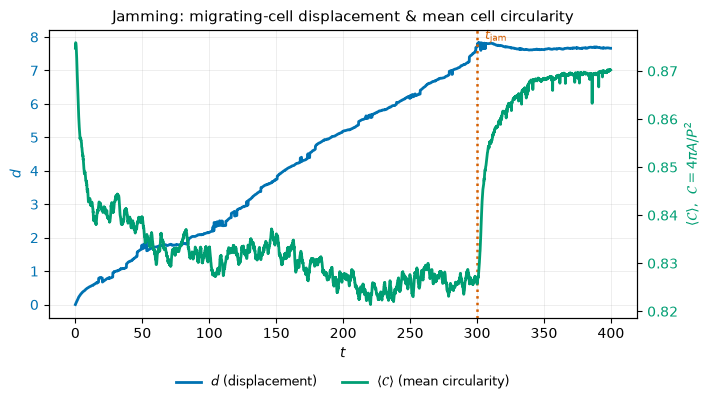

[jamming] final displacement = 7.664


In [7]:
MAKE_GIFS = True

jam_dir = OUT_DIR / "jamming"
jam_path = jam_dir / "history.hf5"
if not jam_path.exists():
    print("no jamming archive — run `python jamming_gradient.py` first")
else:
    hist_j = LoadedHistory(jam_path)
    if MAKE_GIFS:
        save_gif(hist_j, jam_dir / "jamming.gif", PP_RANGE)
    save_stills(hist_j, jam_dir, PP_RANGE)

    trace_j = migrating_trace(hist_j)
    trace_j.to_csv(jam_dir / "migrating_trace.csv", index=False)
    circ_j = circularity_over_time(hist_j)
    circ_j.to_csv(jam_dir / "circularity_over_time.csv", index=False)

    plot_combined_over_time(
        trace_j, circ_j,
        out_path=jam_dir / "displacement_circularity.png",
        title="Jamming: migrating-cell displacement & mean cell circularity",
        jamming_time=JAM_TRIGGER,
    )
    print(f"[jamming] final displacement = {trace_j['displacement'].iloc[-1]:.3f}")

## Gradient scenario

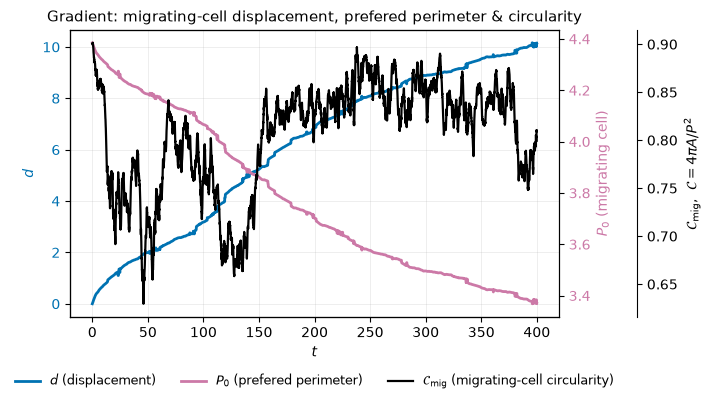

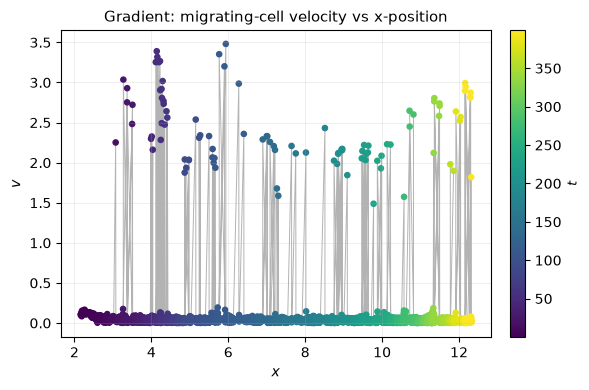

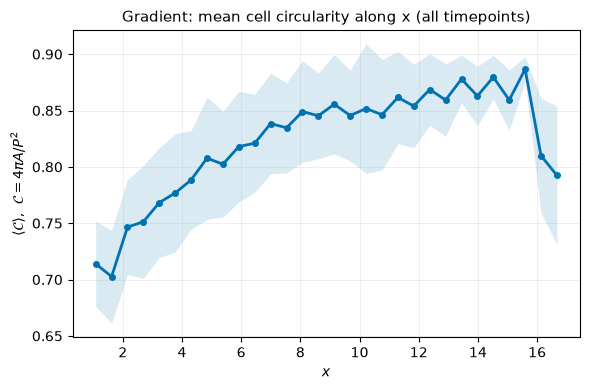

[gradient] final displacement = 10.143
[gradient] migrating-cell circularity: 0.900 -> 0.810


In [8]:
grad_dir = OUT_DIR / "gradient"
grad_path = grad_dir / "history.hf5"
if not grad_path.exists():
    print("no gradient archive — run `python jamming_gradient.py` first")
else:
    hist_g = LoadedHistory(grad_path)
    if MAKE_GIFS:
        save_gif(hist_g, grad_dir / "gradient.gif", PP_RANGE)
    save_stills(hist_g, grad_dir, PP_RANGE)

    trace_g = migrating_trace(hist_g)
    trace_g.to_csv(grad_dir / "migrating_trace.csv", index=False)

    plot_combined_over_time(
        trace_g,
        out_path=grad_dir / "displacement_perimeter.png",
        title="Gradient: migrating-cell displacement, prefered perimeter & circularity",
        with_pref_perimeter=True,
        with_mig_circularity=True,
    )
    plot_velocity_vs_x(trace_g, grad_dir / "migrating_velocity_vs_x.png",
                       "Gradient: migrating-cell velocity vs x-position")

    circ_gx = circularity_along_x(hist_g)
    circ_gx.to_csv(grad_dir / "circularity_along_x.csv", index=False)
    plot_circularity_along_x(circ_gx, grad_dir / "circularity_along_x.png",
                             "Gradient: mean cell circularity along x (all timepoints)")
    print(f"[gradient] final displacement = {trace_g['displacement'].iloc[-1]:.3f}")
    print(f"[gradient] migrating-cell circularity: "
          f"{trace_g['circularity'].iloc[0]:.3f} -> {trace_g['circularity'].iloc[-1]:.3f}")